# 中国公务员考试职位竞争分析与「性价比」职位推荐

**作者项目 · 数据分析端到端实践（数据工程 → 多维分析 → NLP 文本挖掘 → 机器学习建模）**

---

## 项目摘要

本项目基于 **2019–2026 年国考 + 31 省省考共 83 万条真实职位数据**，完成从原始数据清洗到机器学习建模的完整链路：

1. **数据工程**：合并 32 个异构 CSV（83 万行），清洗脏数据、解析 `3:1` 形式的比例字段、规范化学历文本，并工程化构造核心指标 **报录比（报名人数 / 招录人数）**。
2. **多维竞争分析**：从时间趋势、地域、学历、专业、部门五个维度刻画公考竞争格局。
3. **NLP 文本挖掘**：对自由文本 `专业要求` 分词，构建 **专业「机会度」排名**，量化「不限专业」岗位的稀缺性。
4. **机器学习建模**：在**无数据泄漏**约束下，用职位「报名前可知特征」预测报录比（梯度提升回归），并落地一个 **「性价比职位推荐器」**——输入考生画像（专业 / 学历 / 目标省份），推荐预测竞争最低的匹配岗位。

> 核心指标 **报录比 = 报名人数 / 招录人数**，衡量「上岸难度」。全样本中位数约 15，即平均 15 人竞争 1 个岗位，长尾岗位可达数千比一。


## 0. 环境准备与数据加载

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# 中文显示
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Microsoft YaHei", rc={"axes.unicode_minus": False})

PROJECT_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
CLEAN = os.path.join(PROJECT_DIR, "data", "clean", "positions.parquet")
FIG = os.path.join(PROJECT_DIR, "outputs", "figures")
TAB = os.path.join(PROJECT_DIR, "outputs", "tables")
os.makedirs(FIG, exist_ok=True)
os.makedirs(TAB, exist_ok=True)

df = pd.read_parquet(CLEAN)
print(f"数据规模: {df.shape[0]:,} 行 × {df.shape[1]} 列")
df.head(3)


数据规模: 831,407 行 × 34 列


,year,province,area_name,working_address,city,district,department_code,position_code,department_system,department,...,competition_ratio_official,interview_ratio_num,min_degree_level,degree_open_upward,min_degree_name,major_unlimited,major_term_count,report_ratio,heat_level,employ_flexible
0,2020,安徽,安徽,合肥市,合肥市,NaN,109210,300130850014,铁路公安局,上海铁路公安局,...,NaN,3.0,2.0,0.0,本科,0,3,8.5,低竞争(<20),0
1,2020,安徽,安徽,安庆市,安庆市,NaN,109210,300130850015,铁路公安局,上海铁路公安局,...,NaN,3.0,2.0,0.0,本科,0,3,25.0,中竞争(20-50),0
2,2020,安徽,安徽,黄山市,黄山市,NaN,109210,300130850016,铁路公安局,上海铁路公安局,...,NaN,3.0,2.0,0.0,本科,0,1,17.0,低竞争(<20),0


In [2]:
# 关键字段概览
字段中文名 = {
    "year": "年份", "exam_type": "考试类型", "province": "省份", "city": "城市",
    "department_system": "部门系统", "position_name": "职位名称",
    "major_requirement": "专业要求", "min_degree_name": "最低学历",
    "employ_count": "招录人数", "enrollment_count": "报名人数",
    "report_ratio": "报录比", "interview_ratio_num": "面试比例",
}
overview = pd.DataFrame({
    "非空数量": df.notna().sum(),
    "缺失率": (df.isna().mean()).round(3),
    "唯一值": df.nunique(),
}).loc[list(字段中文名.keys())].rename(index=字段中文名)
overview.index.name = "字段"
overview


,非空数量,缺失率,唯一值
字段,,,
年份,831407,0.000,8
考试类型,831407,0.000,2
省份,831407,0.000,31
城市,831407,0.000,560
部门系统,811564,0.024,188
职位名称,831407,0.000,112269
专业要求,825750,0.007,211166
最低学历,827306,0.005,4
招录人数,831407,0.000,86


## 模块 2 · 多维竞争格局分析与可视化

从 **时间 / 地域 / 学历 / 专业 / 部门** 五个维度刻画公考竞争全貌。
所有图表同时保存至 `outputs/figures/`。


### 2.1 招录规模与竞争强度的时间趋势（2019–2026）

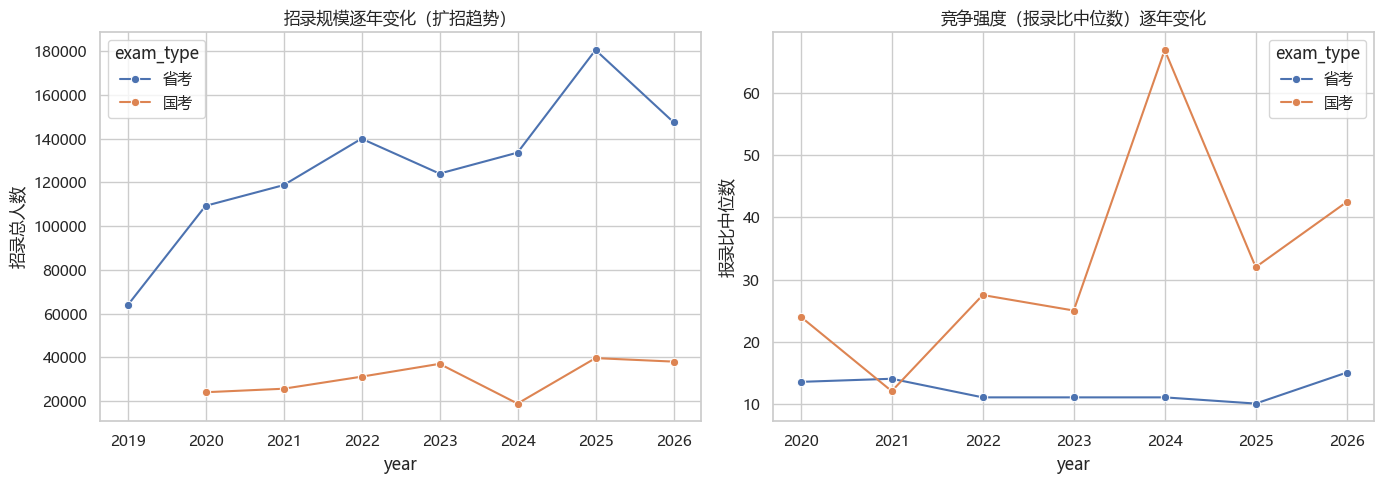

,年份,考试类型,职位数,招录总人数,报名总人数,报录比中位数
0,2019,省考,37327,63813,0.0,NaN
1,2020,国考,13849,24128,1265392.0,24.0
2,2020,省考,70235,109288,1771210.0,13.5
3,2021,国考,13172,25726,924435.0,12.0
4,2021,省考,81702,118748,2630484.0,14.0
5,2022,国考,16745,31242,1793938.0,27.5
6,2022,省考,96815,139978,2324550.0,11.0
7,2023,国考,17655,37100,2175205.0,25.0
8,2023,省考,88375,124025,1533011.0,11.0
9,2024,国考,18948,18948,2552287.0,67.0


In [3]:
trend = df.groupby(["year", "exam_type"]).agg(
    职位数=("position_code", "size"),
    招录总人数=("employ_count", "sum"),
    报名总人数=("enrollment_count", "sum"),
    报录比中位数=("report_ratio", "median"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=trend, x="year", y="招录总人数", hue="exam_type", marker="o", ax=axes[0])
axes[0].set_title("招录规模逐年变化（扩招趋势）")
axes[0].set_ylabel("招录总人数")
sns.lineplot(data=trend, x="year", y="报录比中位数", hue="exam_type", marker="o", ax=axes[1])
axes[1].set_title("竞争强度（报录比中位数）逐年变化")
axes[1].set_ylabel("报录比中位数")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "01_time_trend.png"), dpi=120, bbox_inches="tight")
plt.show()
trend.rename(columns={"year": "年份", "exam_type": "考试类型"})


**解读**：可清楚看到招录规模的扩招趋势，以及疫情后「考公热」推动竞争强度的变化。
国考与省考在体量与竞争度上的结构性差异一目了然。

### 2.2 地域竞争差异：哪个省份最「卷」？

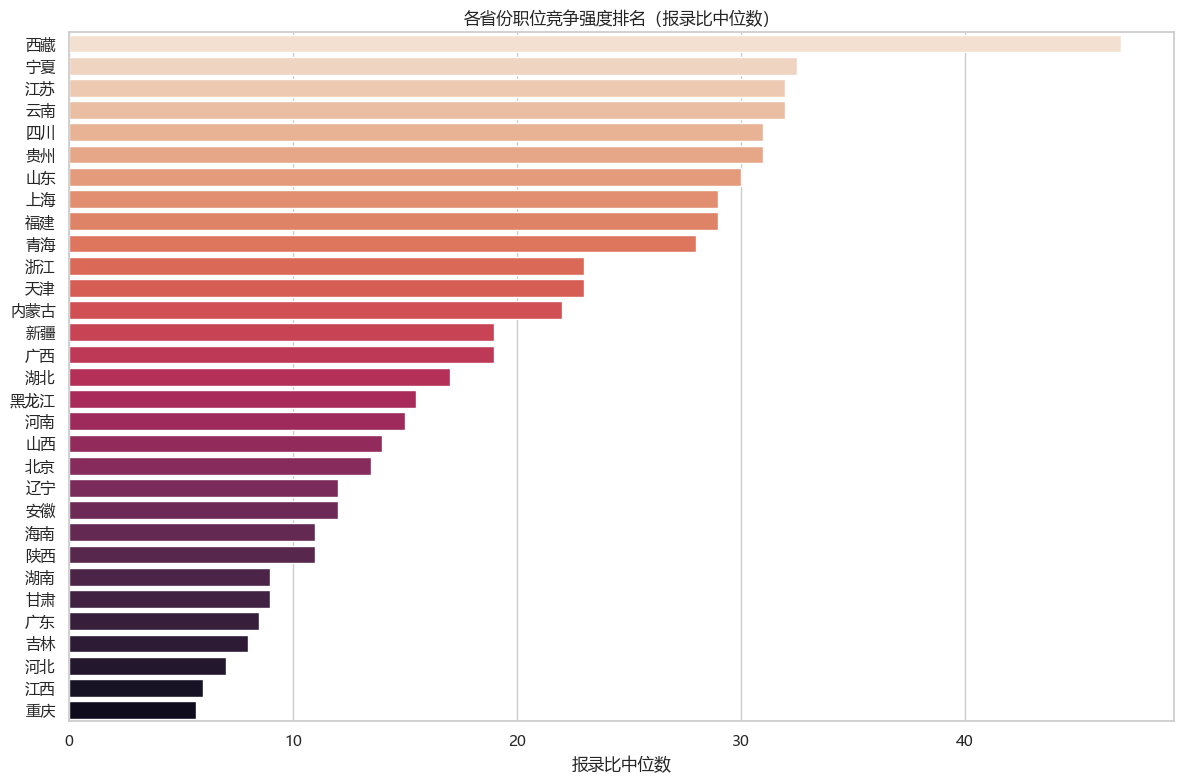

,职位数,招录总人数,报录比中位数
省份,,,
西藏,1996,2608,47.0
宁夏,5794,8220,32.5
江苏,23211,32870,32.0
云南,35023,46015,32.0
四川,5782,9227,31.0
贵州,18802,25329,31.0
山东,6997,11590,30.0
上海,2562,5319,29.0
福建,21830,28228,29.0


In [4]:
prov = (df[df["report_ratio"].notna()]
        .groupby("province")
        .agg(职位数=("position_code","size"),
             招录总人数=("employ_count","sum"),
             报录比中位数=("report_ratio","median"))
        .sort_values("报录比中位数", ascending=False))

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=prov.reset_index(), y="province", x="报录比中位数",
            palette="rocket_r", ax=ax)
ax.set_title("各省份职位竞争强度排名（报录比中位数）")
ax.set_xlabel("报录比中位数"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "02_province_competition.png"), dpi=120, bbox_inches="tight")
plt.show()
prov.rename_axis("省份").head(10)


### 2.3 学历门槛与竞争的关系

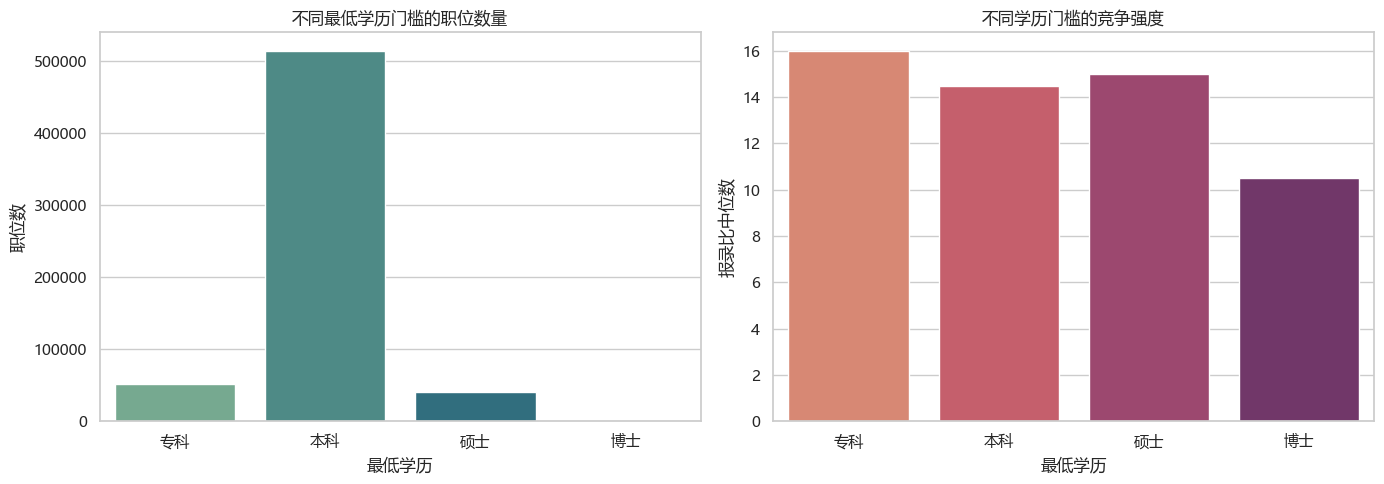

,职位数,报录比中位数,不限专业占比
min_degree_name,,,
专科,51326,16.0,0.741535
本科,513834,14.5,0.198138
硕士,40862,15.0,0.054745
博士,80,10.5,0.000000


In [5]:
deg = (df[df["report_ratio"].notna() & df["min_degree_name"].notna()]
       .groupby("min_degree_name")
       .agg(职位数=("position_code","size"),
            报录比中位数=("report_ratio","median"),
            不限专业占比=("major_unlimited","mean")))
deg = deg.reindex(["专科","本科","硕士","博士"]).dropna(how="all")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=deg.reset_index(), x="min_degree_name", y="职位数", palette="crest", ax=axes[0])
axes[0].set_title("不同最低学历门槛的职位数量"); axes[0].set_xlabel("最低学历")
sns.barplot(data=deg.reset_index(), x="min_degree_name", y="报录比中位数", palette="flare", ax=axes[1])
axes[1].set_title("不同学历门槛的竞争强度"); axes[1].set_xlabel("最低学历")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "03_degree.png"), dpi=120, bbox_inches="tight")
plt.show()
deg


### 2.4 「不限专业」的诅咒：专业限制 vs 竞争强度

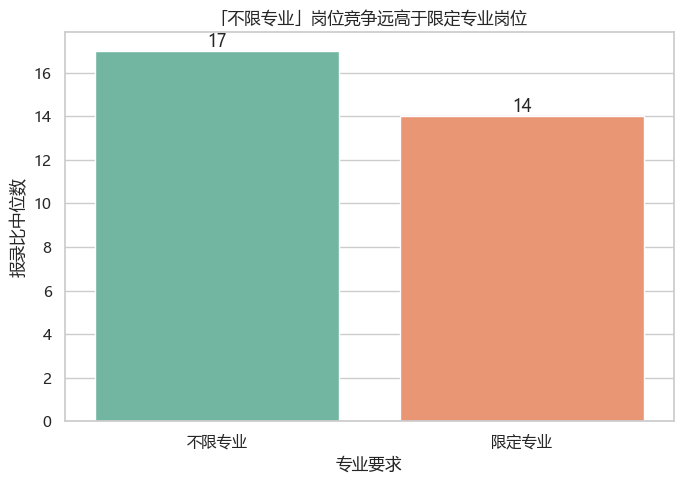

,职位数,报录比中位数,报录比均值
专业要求,,,
不限专业,144031,17.0,35.021884
限定专业,463995,14.0,38.518022


In [6]:
grp = (df[df["report_ratio"].notna()]
       .assign(专业要求=lambda d: np.where(d["major_unlimited"]==1, "不限专业", "限定专业"))
       .groupby("专业要求")
       .agg(职位数=("position_code","size"),
            报录比中位数=("report_ratio","median"),
            报录比均值=("report_ratio","mean")))

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=grp.reset_index(), x="专业要求", y="报录比中位数", palette="Set2", ax=ax)
ax.set_title("「不限专业」岗位竞争远高于限定专业岗位")
for i, v in enumerate(grp["报录比中位数"]):
    ax.text(i, v, f"{v:.0f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "04_major_limited.png"), dpi=120, bbox_inches="tight")
plt.show()
grp


### 2.5 全样本最「卷」职位 TOP 20

In [7]:
hottest = (df[df["report_ratio"].notna() & (df["employ_count"]>=1)]
           .sort_values("report_ratio", ascending=False)
           .loc[:, ["year","exam_type","province","city","department","position_name",
                     "employ_count","enrollment_count","report_ratio"]]
           .head(20).reset_index(drop=True))
hottest = hottest.rename(columns={
    "year": "年份", "exam_type": "考试类型", "province": "省份", "city": "城市",
    "department": "招录部门", "position_name": "职位名称",
    "employ_count": "招录人数", "enrollment_count": "报名人数", "report_ratio": "报录比",
})
hottest.to_csv(os.path.join(TAB, "top20_hottest_positions.csv"), index=False, encoding="utf-8-sig")
hottest


,年份,考试类型,省份,城市,招录部门,职位名称,招录人数,报名人数,报录比
0,2022,国考,西藏,西藏,西藏自治区邮政管理局,一级主任科员及以下,1,17864.0,17864.0
1,2025,国考,北京,北京市,中华职业教育社,联络部一级主任科员及以下,1,10665.0,10665.0
2,2026,国考,云南,德宏傣族景颇族自治州,国家移民管理局瑞丽遣返中心,瑞丽遣返中心执行队一级警长及以下（十三）,1,6332.0,6332.0
3,2023,国考,青海,玉树藏族自治州,国家税务总局青海省税务局,一级行政执法员（三）,1,5710.0,5710.0
4,2026,国考,北京,北京市,中国残联,教育处一级主任科员及以下,1,4706.0,4706.0
5,2024,国考,北京,北京市,NaN,岗位17372,1,4579.0,4579.0
6,2022,国考,北京,北京市,全国总工会,办公室一级主任科员及以下,1,4306.0,4306.0
7,2021,省考,浙江,杭州市,杭州市余杭区人民政府南苑街道办事处,综合管理一级主任科员及以下,1,4125.0,4125.0
8,2024,国考,甘肃,兰州市,NaN,岗位18948,1,4039.0,4039.0
9,2025,国考,北京,北京市,国家知识产权局,审查部门（三）一级主任科员及以下,1,3875.0,3875.0


## 模块 3 · 专业要求文本挖掘（NLP）

`major_requirement` 是自由文本（如「经济与贸易类、工商管理类、计算机类」）。
本模块用 **jieba 分词 + 词频统计** 量化各专业/专业类的**岗位机会度**，
并分析「不限专业」岗位的时间与地域分布。


### 3.1 高频专业类词云级排名（哪些专业岗位机会最多）

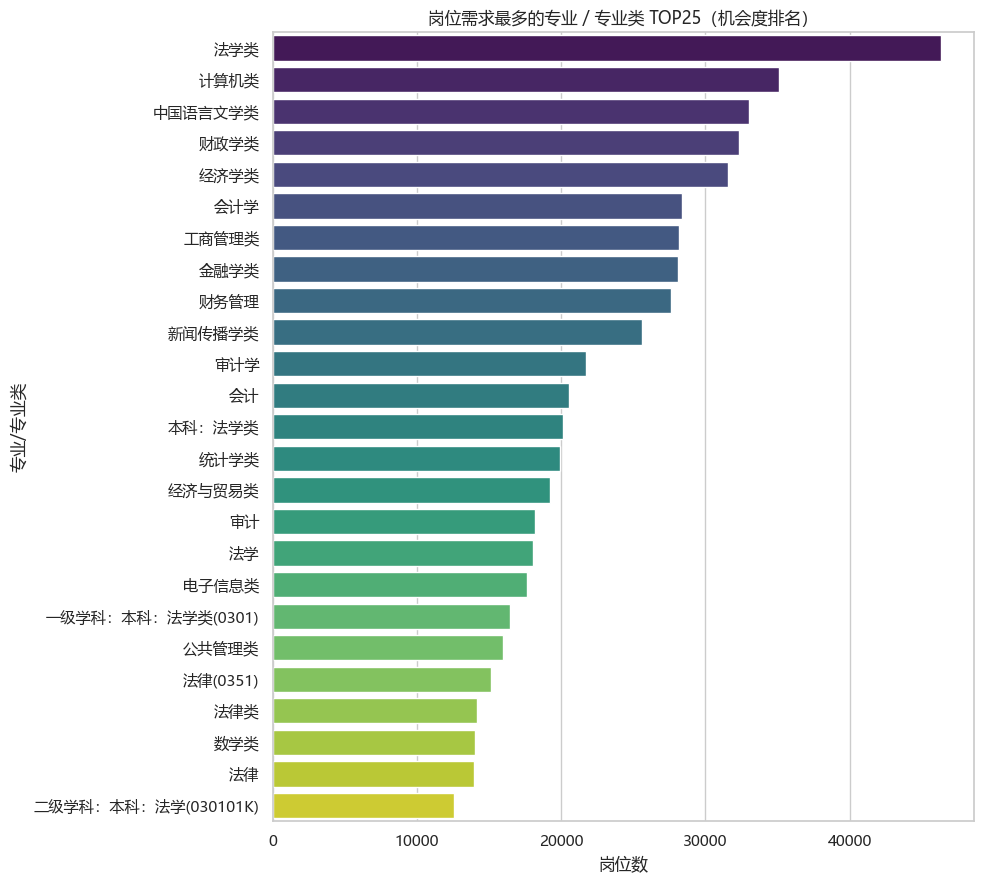

,专业/专业类,岗位数
0,法学类,46307
1,计算机类,35122
2,中国语言文学类,33053
3,财政学类,32305
4,经济学类,31540
5,会计学,28351
6,工商管理类,28183
7,金融学类,28133
8,财务管理,27602
9,新闻传播学类,25613


In [8]:
import jieba
from collections import Counter

# 只统计「限定专业」的岗位文本
texts = df.loc[df["major_unlimited"]==0, "major_requirement"].dropna()

# 直接按分隔符切出专业类，比分词更贴合语义
import re
counter = Counter()
for t in texts:
    for term in re.split(r"[、,，;；/]", t):
        term = term.strip()
        if len(term) >= 2:
            counter[term] += 1

top_major = pd.DataFrame(counter.most_common(25), columns=["专业/专业类", "岗位数"])
fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=top_major, y="专业/专业类", x="岗位数", palette="viridis", ax=ax)
ax.set_title("岗位需求最多的专业 / 专业类 TOP25（机会度排名）")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "05_top_majors.png"), dpi=120, bbox_inches="tight")
plt.show()
top_major.head(15)


### 3.2 jieba 分词提取专业关键词（细粒度词频）

In [9]:
tokens = Counter()
for t in texts.sample(min(80000, len(texts)), random_state=42):
    for w in jieba.cut(t):
        w = w.strip()
        if len(w) >= 2 and not re.match(r"^[、,，;；/\s]+$", w):
            tokens[w] += 1
kw = pd.DataFrame(tokens.most_common(30), columns=["关键词","频次"])
kw.head(20)


Building prefix dict from the default dictionary ...


Loading model from cache C:\Users\asus\AppData\Local\Temp\jieba.cache


Loading model cost 0.668 seconds.


Prefix dict has been built successfully.


,关键词,频次
0,学科,54549
1,本科,47463
2,研究生,46608
3,工程,32424
4,一级,25563
5,法学,23490
6,二级,23198
7,经济学,19491
8,管理,18397
9,法学类,17405


### 3.3 「不限专业」岗位占比的时间与地域分布

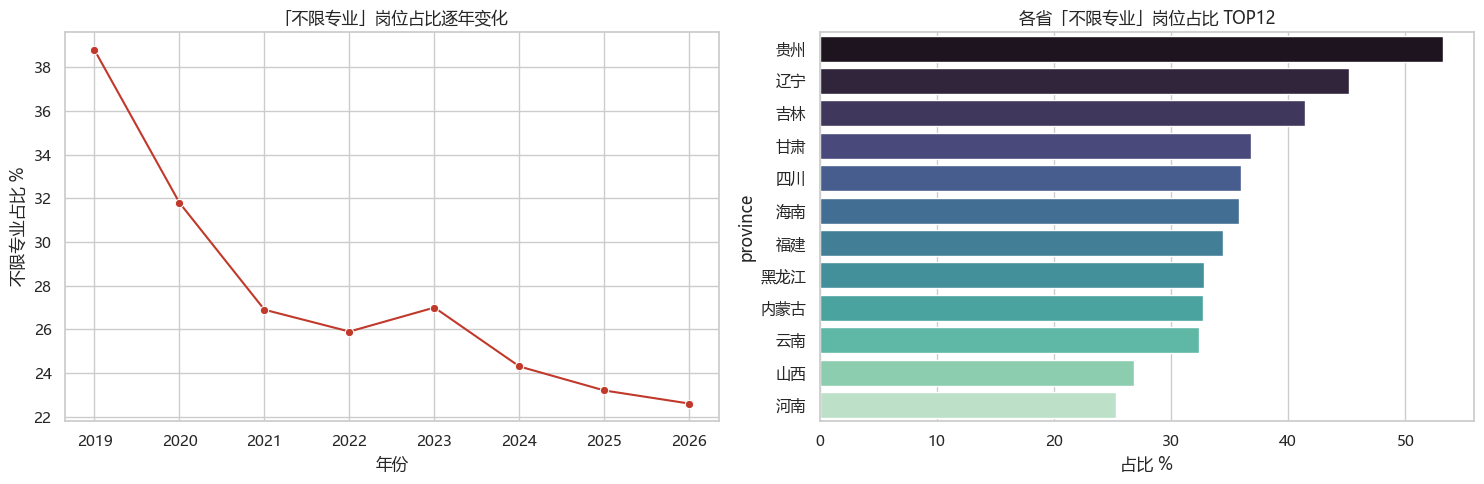

In [10]:
pivot = (df.groupby("year")["major_unlimited"].mean()*100).round(1)
prov_unlim = (df.groupby("province")["major_unlimited"].mean()*100).round(1).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(x=pivot.index, y=pivot.values, marker="o", ax=axes[0], color="#c0392b")
axes[0].set_title("「不限专业」岗位占比逐年变化"); axes[0].set_ylabel("不限专业占比 %"); axes[0].set_xlabel("年份")
sns.barplot(x=prov_unlim.head(12).values, y=prov_unlim.head(12).index, palette="mako", ax=axes[1])
axes[1].set_title("各省「不限专业」岗位占比 TOP12"); axes[1].set_xlabel("占比 %")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "06_major_unlimited_dist.png"), dpi=120, bbox_inches="tight")
plt.show()


## 模块 4 · 机器学习建模

### 目标
在 **报名前可知的职位特征** 基础上，预测该职位的 **报录比（竞争强度）**。这是一个真实、可落地的场景：
考生在报名前无法看到最终报名人数，但可以借助模型对「岗位会有多卷」给出预测，从而做出更优选择。

### 防数据泄漏原则
- **只用报名前可知的特征**：年份、国/省考、省份、部门系统、招录人数、学历门槛、专业限制等。
- **严格排除结果类字段**：`enrollment_count`（目标分子）、官方竞争比、系统/部门排名比等。


### 4.1 构造建模数据集与特征

In [11]:
model_df = df[df["report_ratio"].notna() & (df["employ_count"] >= 1)].copy()

# 目标：对报录比做 winsorize(1%) 截尾 + log1p，缓解长尾
cap = model_df["report_ratio"].quantile(0.99)
model_df["y"] = np.log1p(model_df["report_ratio"].clip(upper=cap))

# 高基数字段降维：部门系统只保留 TOP30，其余归为「其他」
top_sys = model_df["department_system"].value_counts().head(30).index
model_df["dep_sys"] = np.where(model_df["department_system"].isin(top_sys),
                                model_df["department_system"], "其他")

cat_features = ["考试类型", "省份", "部门系统", "最低学历"]
num_features = ["年份", "招录人数", "是否不限专业", "专业数量", "学历及以上", "面试比例"]
特征映射 = {
    "exam_type": "考试类型", "province": "省份", "dep_sys": "部门系统",
    "min_degree_name": "最低学历", "year": "年份", "employ_count": "招录人数",
    "major_unlimited": "是否不限专业", "major_term_count": "专业数量",
    "degree_open_upward": "学历及以上", "interview_ratio_num": "面试比例",
}

X = model_df[list(特征映射.keys())].rename(columns=特征映射).copy()
for c in cat_features:
    X[c] = X[c].fillna("未知").astype("category")
X["面试比例"] = X["面试比例"].fillna(X["面试比例"].median())
X["学历及以上"] = X["学历及以上"].fillna(0)
y = model_df["y"]
print(f"建模样本: {len(X):,} 行, 特征数: {X.shape[1]}")
print(f"报录比截尾上限(p99): {cap:.1f}")
X.head(3)


建模样本: 608,026 行, 特征数: 10
报录比截尾上限(p99): 362.0


,考试类型,省份,部门系统,最低学历,年份,招录人数,是否不限专业,专业数量,学历及以上,面试比例
0,国考,安徽,其他,本科,2020,8,0,3,0.0,3.0
1,国考,安徽,其他,本科,2020,2,0,3,0.0,3.0
2,国考,安徽,其他,本科,2020,2,0,1,0.0,3.0


### 4.2 训练梯度提升回归模型（对比线性回归 baseline）

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# baseline: Ridge + OneHot
pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), cat_features),
    ("num", StandardScaler(), num_features),
])
ridge = Pipeline([("pre", pre), ("m", Ridge(alpha=1.0))])
ridge.fit(X_train, y_train)
pred_r = ridge.predict(X_test)

# 主模型: HistGradientBoosting（原生支持类别特征）
hgb = HistGradientBoostingRegressor(
    max_iter=400, learning_rate=0.08, max_depth=8,
    categorical_features=cat_features, random_state=42)
hgb.fit(X_train, y_train)
pred_h = hgb.predict(X_test)

def report(name, y_true, y_pred):
    # 还原到原始报录比尺度评估更直观
    inv_t, inv_p = np.expm1(y_true), np.expm1(y_pred)
    print(f"{name:>22} | log-R2={r2_score(y_true,y_pred):.3f} | "
          f"原尺度 MAE={mean_absolute_error(inv_t,inv_p):.1f} | "
          f"原尺度中位绝对误差={np.median(np.abs(inv_t-inv_p)):.1f}")

report("Ridge (baseline)", y_test, pred_r)
report("HistGradientBoosting", y_test, pred_h)


      Ridge (baseline) | log-R2=0.267 | 原尺度 MAE=26.3 | 原尺度中位绝对误差=9.3
  HistGradientBoosting | log-R2=0.453 | 原尺度 MAE=23.4 | 原尺度中位绝对误差=8.1


### 4.3 模型解读：哪些因素决定一个岗位有多「卷」？

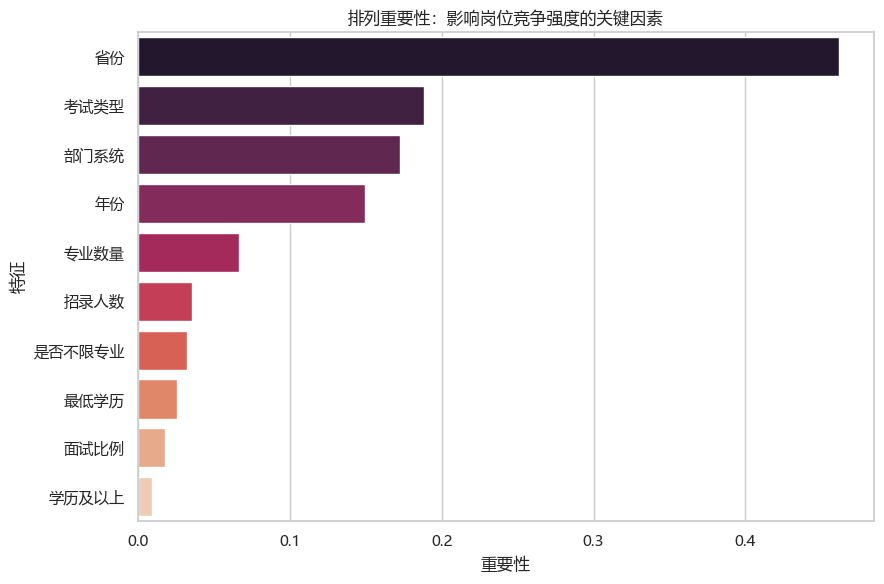

,特征,重要性
1,省份,0.461737
0,考试类型,0.188219
2,部门系统,0.172255
4,年份,0.149443
7,专业数量,0.066386
5,招录人数,0.035318
6,是否不限专业,0.032249
3,最低学历,0.025725
9,面试比例,0.017746
8,学历及以上,0.009036


In [13]:
from sklearn.inspection import permutation_importance

sample_idx = np.random.RandomState(0).choice(len(X_test), size=min(8000, len(X_test)), replace=False)
imp = permutation_importance(hgb, X_test.iloc[sample_idx], y_test.iloc[sample_idx],
                             n_repeats=5, random_state=0, n_jobs=-1)
imp_df = (pd.DataFrame({"特征": X.columns, "重要性": imp.importances_mean})
          .sort_values("重要性", ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=imp_df, y="特征", x="重要性", palette="rocket", ax=ax)
ax.set_title("排列重要性：影响岗位竞争强度的关键因素")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "07_feature_importance.png"), dpi=120, bbox_inches="tight")
plt.show()
imp_df


### 4.4 预测 vs 实际 拟合效果

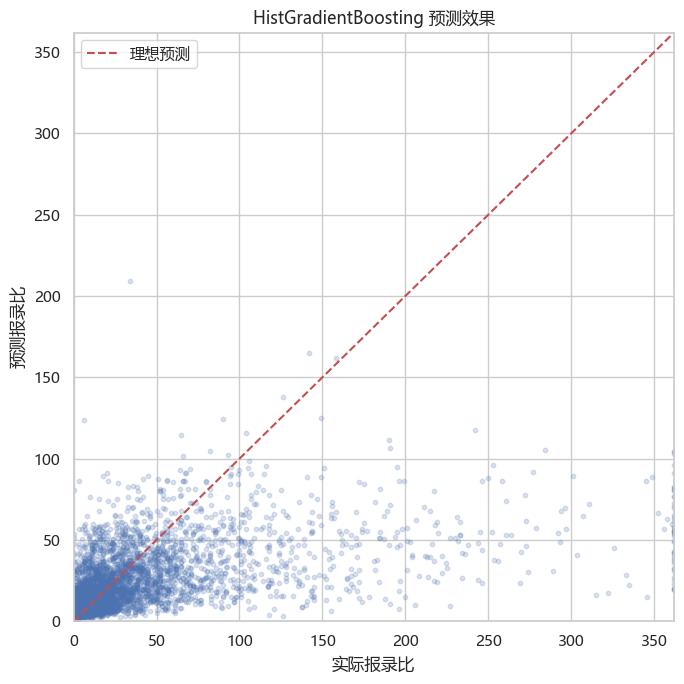

In [14]:
fig, ax = plt.subplots(figsize=(7, 7))
s = np.random.RandomState(1).choice(len(y_test), size=min(5000, len(y_test)), replace=False)
ax.scatter(np.expm1(y_test.iloc[s]), np.expm1(pred_h[s]), alpha=0.2, s=10)
lim = [0, np.expm1(y_test).quantile(0.99)]
ax.plot(lim, lim, "r--", label="理想预测")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("实际报录比"); ax.set_ylabel("预测报录比")
ax.set_title("HistGradientBoosting 预测效果"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, "08_pred_vs_true.png"), dpi=120, bbox_inches="tight")
plt.show()


## 模块 4（应用）· 「性价比职位推荐器」

综合前述模型与规则，构建一个面向考生的实用工具：
输入 **专业关键词、学历、目标省份**，从最新一年（2026）职位中筛选**符合报考条件**的岗位，
再按**模型预测竞争强度从低到高**排序，推荐「性价比」最高的岗位。


In [15]:
def recommend_positions(major_keyword=None, degree="本科", province=None,
                        exam_type=None, year=None, top_n=10):
    # 根据考生画像推荐低竞争的匹配岗位
    level_map = {"专科":1, "本科":2, "硕士":3, "博士":4}
    cand = df.copy()
    if year is None:
        year = int(cand["year"].max())
    cand = cand[cand["year"] == year]
    if province:
        cand = cand[cand["province"] == province]
    if exam_type:
        cand = cand[cand["exam_type"] == exam_type]
    # 学历匹配：考生学历 >= 岗位最低门槛
    my_level = level_map.get(degree, 2)
    cand = cand[cand["min_degree_level"].fillna(my_level) <= my_level]
    # 专业匹配：不限专业 或 专业要求含关键词
    if major_keyword:
        mask = (cand["major_unlimited"] == 1) | \
               cand["major_requirement"].fillna("").str.contains(major_keyword)
        cand = cand[mask]
    if cand.empty:
        return pd.DataFrame({"提示": ["无匹配岗位，请放宽条件"]})

    # 用模型预测竞争强度
    feat = pd.DataFrame({
        "考试类型": cand["exam_type"],
        "省份": cand["province"],
        "部门系统": np.where(cand["department_system"].isin(top_sys), cand["department_system"], "其他"),
        "最低学历": cand["min_degree_name"].fillna("未知"),
        "年份": cand["year"],
        "招录人数": cand["employ_count"].fillna(1),
        "是否不限专业": cand["major_unlimited"],
        "专业数量": cand["major_term_count"],
        "学历及以上": cand["degree_open_upward"].fillna(0),
        "面试比例": cand["interview_ratio_num"].fillna(3),
    })
    for c in cat_features:
        feat[c] = feat[c].astype("category")
    cand = cand.assign(预测报录比=np.expm1(hgb.predict(feat[cat_features+num_features])))
    out = (cand.sort_values("预测报录比")
           .loc[:, ["province","city","department","position_name",
                     "major_requirement","min_degree_name","employ_count","预测报录比"]]
           .head(top_n).reset_index(drop=True)
           .rename(columns={"province": "省份", "city": "城市", "department": "招录部门",
                            "position_name": "职位名称", "major_requirement": "专业要求",
                            "min_degree_name": "最低学历", "employ_count": "招录人数"}))
    out["预测报录比"] = out["预测报录比"].round(1)
    return out

print("示例：本科 · 计算机专业 · 目标广东省 · 竞争最低的岗位推荐")
recommend_positions(major_keyword="计算机", degree="本科", province="广东", top_n=10)


示例：本科 · 计算机专业 · 目标广东省 · 竞争最低的岗位推荐


,省份,城市,招录部门,职位名称,专业要求,最低学历,招录人数,预测报录比
0,广东,清远市,连州市人民法院,综合办公室（司法警察大队）一级科员,本科：计算机类(B0809),本科,1,5.2
1,广东,肇庆市,四会市人民法院,综合办公室（司法警察大队）一级科员,研究生：计算机科学与技术(A0812)；本科：计算机类(B0809),本科,1,5.6
2,广东,清远市,连南瑶族自治县人民法院,综合办公室（司法警察大队）一级科员,研究生：计算机科学与技术(A0812)；本科：计算机类(B0809),本科,1,5.6
3,广东,韶关市,南雄市人民法院,司法行政部门二级主任科员以下,研究生：工学(A08)；本科：计算机类(B0809),本科,1,5.6
4,广东,茂名市,信宜市人民法院,综合办公室一级科员,"研究生：计算机科学与技术(A0812)；本科：计算机科学与技术(B080901),网络工程(...",本科,1,5.9
5,广东,广州市,广州市从化区人民法院,综合办公室一级科员,"研究生：计算机科学与技术(A0812)；本科：计算机科学与技术(B080901),软件工程(...",本科,1,5.9
6,广东,佛山市,佛山市公安局,科技信息化支队二级警长以下,"研究生：计算机科学与技术(A0812),计算机技术硕士（专业硕士）(A084004)；本科：...",本科,2,6.6
7,广东,佛山市,佛山市公安局南海分局,基层派出所二级警长以下,"研究生：信息与通信工程(A0810),计算机科学与技术(A0812),通信工程硕士（专业硕士...",本科,5,6.8
8,广东,汕头市,汕头市濠江区司法局,礐石司法所1名、马滘司法所1名、滨海司法所1名一级科员,"研究生：法学(A0301),公安学(A0306),计算机科学与技术(A0812)；本科：法学...",本科,3,7.1
9,广东,潮州市,潮州市饶平县公安局,东山派出所1名、新塘派出所1名、建饶派出所1名二级警长以下,"研究生：信息与通信工程(A0810),计算机科学与技术(A0812),公安技术(A0838)...",本科,3,7.1


In [16]:
print("示例：硕士 · 会计专业 · 全国范围 · 性价比岗位")
recommend_positions(major_keyword="会计", degree="硕士", top_n=10)


示例：硕士 · 会计专业 · 全国范围 · 性价比岗位


,省份,城市,招录部门,职位名称,专业要求,最低学历,招录人数,预测报录比
0,河北,石家庄市,新华区,司法行政职位B,二级学科：研究生：财政学(020203)、会计学(120201)、会计(125300)、审计...,硕士,1,1.4
1,河北,石家庄市,鹿泉区,司法行政职位,二级学科：研究生：财政学(020203)、会计学(120201)、会计(125300)、审计...,硕士,1,1.4
2,河北,承德市,市直属,执法勤务职位E,二级学科：本科：国际经济与贸易(020401)、金融学(020301K)、金融审计(0203...,本科,1,1.6
3,河北,承德市,滦平县,执法勤务职位F,二级学科：本科：金融学(020301K)、会计学(120203K)、审计学(120207)、...,本科,1,1.6
4,河北,承德市,市直属,执法勤务职位E,二级学科：本科：会计学(120203K)、审计学(120207)、财务管理(120204)、...,本科,1,1.6
5,河北,唐山市,迁安市,执法勤务职位A,二级学科：本科：法学(030101K)、知识产权(030102T)、侦查学(030602K)...,本科,2,1.6
6,河北,邯郸市,市直属,执法勤务职位A,二级学科：本科：金融学(020301K)、会计学(120203K)、国际经济与贸易(0204...,本科,2,1.6
7,河北,张家口市,阳原县,执法勤务职位C,二级学科：本科：会计学(120203K)、财务管理(120204)、网络工程(080903)...,本科,1,1.6
8,河北,秦皇岛市,市直属,执法勤务职位B,二级学科：本科：工商管理(120201K)、财务管理(120204)、会计学(120203K...,本科,2,1.6
9,河北,石家庄市,高邑县,执法勤务职位,二级学科：本科：法学(030101K)、知识产权(030102T)、网络工程(080903)...,本科,3,1.7


## 结论与项目亮点

### 主要发现
1. **扩招与竞争并存**：2019–2026 招录规模持续扩大，但报名热度增长更快，整体竞争强度上升。
2. **地域分化明显**：不同省份报录比中位数差异显著，反映区域「考公热」与岗位供给的错配。
3. **不限专业 = 高竞争**：「不限专业」岗位报录比中位数远高于限定专业岗位，是「千军万马」的主战场。
4. **岗位机会结构**：财会、法学、计算机、经济类等专业岗位需求量最大，专业越对口选择面越广。
5. **可预测性**：仅用报名前可知特征即可对竞争强度做出有意义的预测，招录人数、省份、部门系统、专业限制是最关键因素。
